<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_04/assignments/assignment_04_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT_SCI 465: Advanced Electron Microscopy & Diffraction
## Week 03 & 04 Combined Assignment
**Classical, ML, and Deep Learning Approaches to Microscopy Analysis**

**Dataset:** DOPAD (Dataset Of nanoPArticle Detection) - TEM nanoparticle images for detection and classification  
**Dataset Source:** https://dopad.github.io/

## Objective
Compare classical computer vision, machine learning, and deep learning approaches on the same electron microscopy dataset. Progress from traditional image processing through supervised and unsupervised learning to modern deep learning, enabling direct quantitative comparison of all methods.

## Task 1 · Classical Image Analysis Pipeline
- [ ] Apply noise reduction (Gaussian, median, or FFT filtering) and compute signal-to-noise ratio before and after using $SNR = u / igma$.
- [ ] Enhance contrast via histogram equalization or CLAHE (clip limit 0.01-0.03).
- [ ] Segment features using Otsu thresholding followed by Watershed to separate touching particles.
- [ ] Quantify morphology with `regionprops` (area, diameter, eccentricity, solidity) and export measurements to `classical_results.csv`.
- [ ] Create a four-panel figure: raw image, filtered/enhanced result, segmented labels, particle size distribution.

In [69]:
# Task 1 setup: imports and data loading
from pathlib import Path
import numpy as np
import pandas as pd
from skimage import exposure, filters, measure, morphology, segmentation
from skimage.io import imread
from scipy import fft
import matplotlib.pyplot as plt
import os

# DOPAD dataset: download from https://dopad.github.io/docs/download/
# After extraction, adjust IMAGE_DIR to your local path

# Use absolute path to ensure it works regardless of kernel working directory
IMAGE_DIR = Path('/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/raw_data')

print(f"Current working directory: {os.getcwd()}")
print(f"IMAGE_DIR: {IMAGE_DIR}")
print(f"IMAGE_DIR exists: {IMAGE_DIR.exists()}")

# Example: load a TEM image from DOPAD
# For PNG/standard formats:
if IMAGE_DIR.exists():
    sample_images = sorted(list(IMAGE_DIR.glob('*.png')) + list(IMAGE_DIR.glob('*.tif')))
    if sample_images:
        raw_image = imread(str(sample_images[0]))
        print(f"Loaded: {sample_images[0].name}, Shape: {raw_image.shape}")
        print(f"Total images available: {len(sample_images)}")
    else:
        print("No images found in DOPAD directory")
else:
    raw_image = None
    print("IMAGE_DIR path not found. Please download DOPAD dataset and update path.")

Current working directory: /Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments
IMAGE_DIR: /Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/raw_data
IMAGE_DIR exists: True
Loaded: 11500X00.png, Shape: (416, 416, 4)
Total images available: 200


In [70]:
notebook_dir = Path.cwd()
IMAGE_DIR = notebook_dir / 'raw_data'
OUTPUT_DIR = notebook_dir
print(f'Notebook directory: {notebook_dir}')
print(f'Image directory: {IMAGE_DIR}')
print(f'Image directory exists: {IMAGE_DIR.exists()}')
print('Loading DOPAD dataset...')
image_files = sorted(list(IMAGE_DIR.glob('*.png')))
print(f'Found {len(image_files)} images')

n_samples = 100
image_files = image_files[:n_samples]
print(f'Using {len(image_files)} images for analysis')

Notebook directory: /Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments
Image directory: /Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/raw_data
Image directory exists: True
Loading DOPAD dataset...
Found 200 images
Using 100 images for analysis


In [78]:
# Task 1 processing: filtering, enhancement, segmentation, quantification
# HINTS for Task 1:
# 1. Filtering: Use filters.median() or filters.gaussian() from skimage.filters
#    Compare SNR before and after filtering to see improvement
# 2. Enhancement: Use exposure.equalize_adapthist() with clip_limit around 0.025
#    This will increase contrast without oversaturation
# 3. Segmentation: After Otsu thresholding, use scipy.ndimage.distance_transform_edt()
#    to find marker positions for Watershed
# 4. Regionprops: Pass intensity_image parameter to get min/max/mean intensity
#    Example: measure.regionprops(labels, intensity_image=enhanced_image)
# 5. Export: Use pd.DataFrame.to_csv() to save measurements

import numpy as np
from scipy import fftpack
from skimage import io
from scipy import ndimage
from skimage import filters, morphology, segmentation

# Load sample image
raw_image = imread(str(image_files[0]))

# Convert RGB to grayscale if needed
if len(raw_image.shape) == 3:
    raw_image = raw_image[:, :, 0] if raw_image.shape[2] >= 3 else np.mean(raw_image, axis=2)

# Normalize
raw_image = raw_image.astype(np.float32) / 255.0

print(f"Loaded image from: {image_files[0].name}")
print(f"Image shape: {raw_image.shape}")
print(f"Image dtype: {raw_image.dtype}")
print(f"Image min/max: {raw_image.min():.4f} / {raw_image.max():.4f}")

def compute_snr(image: np.ndarray) -> float:
    signal = np.mean(image)
    noise = np.std(image)
    return float(signal / noise) if noise else np.inf

# Filtering hint: Try median filter for salt-and-pepper noise
# filtered_image = filters.median(raw_image, footprint=morphology.disk(3))

# Compute SNR before filtering
snr_0 = compute_snr(raw_image)
print(f"SNR before filtering: {snr_0:.4f}")

# Gaussian filtering
gaussian = filters.gaussian(raw_image, sigma=1.0)
snr_gaussian = compute_snr(gaussian)

# Median filtering
median = filters.median(raw_image, footprint=morphology.disk(3))
snr_median = compute_snr(median)

# FFT filtering
# raw_image = your 2D grayscale image
image = raw_image.astype(float)

# 2D FFT
F = fftpack.fft2(image)
Fshift = fftpack.fftshift(F)  # move zero-frequency to center
#Create a Gaussian low-pass filter
rows, cols = image.shape
x = np.linspace(-0.5, 0.5, cols)
y = np.linspace(-0.5, 0.5, rows)
X, Y = np.meshgrid(x, y)
radius = np.sqrt(X**2 + Y**2)
sigma = 0.05  # smaller sigma → more aggressive smoothing
H = np.exp(-(radius**2) / (2 * sigma**2))  # low-pass Gaussian
# Apply filter in frequency domain
Ffiltered = Fshift * H
#Inverse FFT to get smoothed image
F_ishift = fftpack.ifftshift(Ffiltered)
lowpass_image = np.real(fftpack.ifft2(F_ishift))
snr_lowpass = compute_snr(lowpass_image)

print(f"SNR after Gaussian filtering: {snr_gaussian:.4f}")
print(f"SNR after Median filtering: {snr_median:.4f}")
print(f"SNR after FFT low-pass filtering: {snr_lowpass:.4f}")

# Enhancement hint: CLAHE improves local contrast
# enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.025)
filtered_image = median
enhanced_clahe = exposure.equalize_adapthist(filtered_image, clip_limit=0.025)
enhanced_image = enhanced_clahe
print(f"Enhanced image range: [{enhanced_image.min():.3f}, {enhanced_image.max():.3f}]")

# Segmentation hint: Use Otsu's threshold followed by watershed
# threshold = filters.threshold_otsu(enhanced_image)
# binary = enhanced_image > threshold
# Then use distance transform + watershed to separate particles

# Threshold the enhanced image
threshold = filters.threshold_otsu(enhanced_image)
binary = enhanced_image > threshold

# Remove small objects (classic API)
binary = morphology.remove_small_objects(binary.astype(bool), min_size=10)  

# Remove small holes (classic API)
binary = morphology.remove_small_holes(binary.astype(bool), area_threshold=10)

# Distance transform for watershed
distance = ndimage.distance_transform_edt(binary)

# Find peaks for watershed markers
coords = ndimage.label(binary)[0]
local_maxima = morphology.local_maxima(distance, indices=False)
markers, _ = ndimage.label(local_maxima)

# Apply watershed
labels = segmentation.watershed(-distance, markers=markers, mask=binary)

print(f"Otsu threshold: {threshold:.4f}")
print(f"Number of particles detected: {labels.max()}")


Loaded image from: 11500X00.png
Image shape: (416, 416)
Image dtype: float32
Image min/max: 0.0000 / 1.0000
SNR before filtering: 4.8529
SNR after Gaussian filtering: 4.8994
SNR after Median filtering: 4.8865
SNR after FFT low-pass filtering: 4.9949
Enhanced image range: [0.000, 1.000]
Otsu threshold: 0.6387
Number of particles detected: 391


In [79]:
# Morphology hint: Extract area, perimeter, eccentricity, solidity, equivalent_diameter
# Store in a DataFrame, then save with measurements.to_csv()

from skimage import measure
import pandas as pd

# Compute region properties
regions = measure.regionprops(labels, intensity_image=enhanced_image)

# Build measurements dataframe
measurements_list = []
for region in regions:
    measurements_list.append({
        'Label': region.label,
        'Area': region.area,
        'Perimeter': region.perimeter,
        'Eccentricity': region.eccentricity,
        'Solidity': region.solidity,
        'Equivalent Diameter': region.equivalent_diameter_area,  # updated
        'Centroid_x': region.centroid[1],
        'Centroid_y': region.centroid[0],
        'min_intensity': region.intensity_min,                  # updated
        'max_intensity': region.intensity_max,                  # updated
        'mean_intensity': region.intensity_mean                 # updated
    })

measurements = pd.DataFrame(measurements_list)
print(f"Total particles: {len(measurements)}")
print(measurements.describe())
measurements.to_csv('classical_results.csv', index=False)


Total particles: 391
            Label         Area   Perimeter  Eccentricity    Solidity  \
count  391.000000   391.000000  391.000000    391.000000  391.000000   
mean   196.000000   339.416880   67.632728      0.821602    0.879335   
std    113.016223   821.508133   60.726526      0.166491    0.065477   
min      1.000000    11.000000    9.035534      0.202119    0.530915   
25%     98.500000    46.000000   29.899495      0.726514    0.849837   
50%    196.000000   108.000000   49.591883      0.843153    0.882353   
75%    293.500000   255.000000   86.041631      0.974761    0.921859   
max    391.000000  8712.000000  442.403066      0.999540    1.000000   

       Equivalent Diameter  Centroid_x  Centroid_y  min_intensity  \
count           391.000000  391.000000  391.000000     391.000000   
mean             15.826913  179.781505  251.258352       0.649506   
std              13.495689  111.728315  100.339299       0.059496   
min               3.742410    1.630769   16.578345    

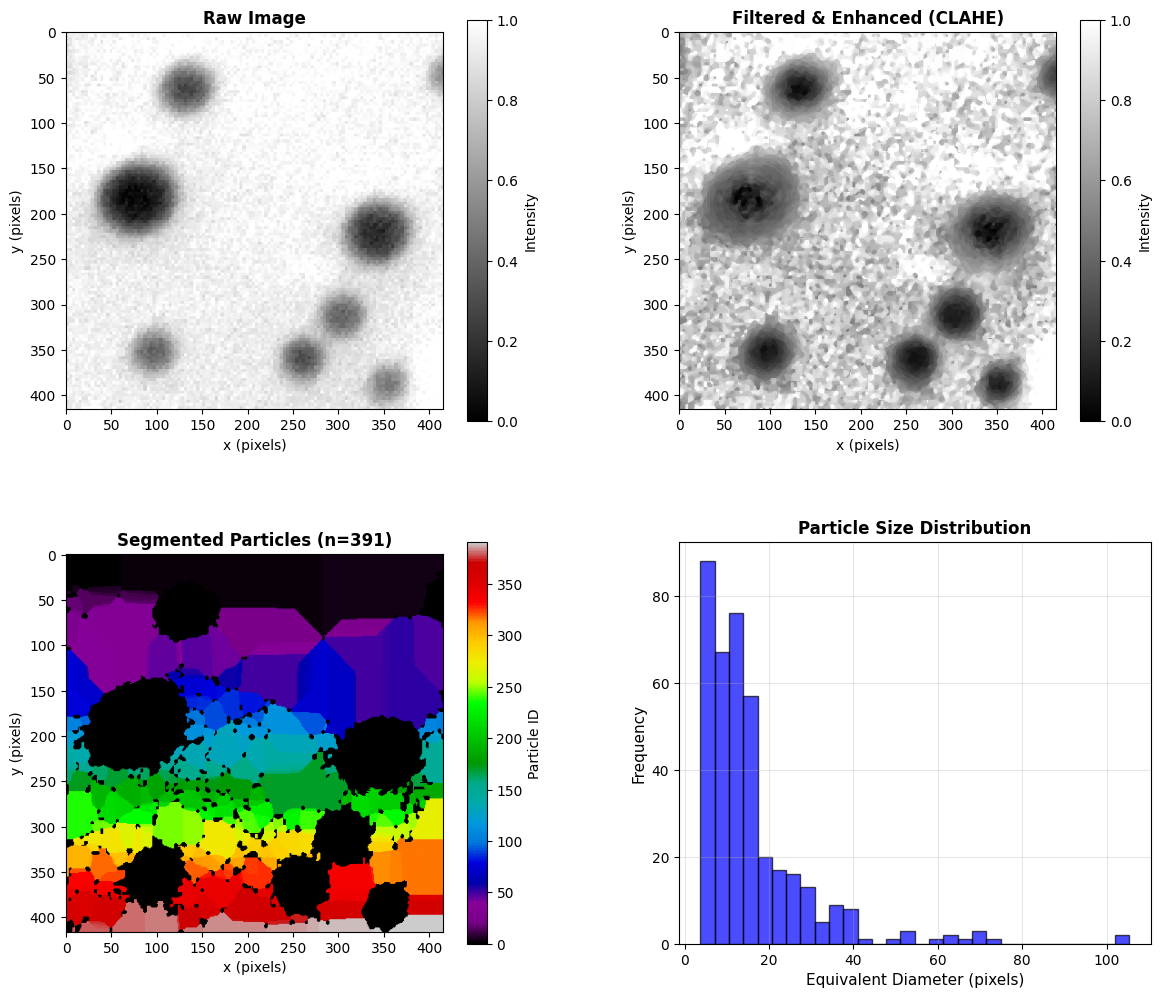

In [80]:
# Visualization hint: Create 2x2 subplot figure with:
# [Raw image] [Enhanced/Filtered]
# [Segmented labels] [Size distribution histogram]
# Use imshow() for images and hist() for distribution

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# Raw Image
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(raw_image, cmap='gray')
ax1.set_title('Raw Image', fontsize=12, fontweight='bold')
ax1.set_xlabel('x (pixels)')
ax1.set_ylabel('y (pixels)')
plt.colorbar(im1, ax=ax1, label='Intensity')

# Filtered and Enhanced
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(enhanced_image, cmap='gray')
ax2.set_title('Filtered & Enhanced (CLAHE)', fontsize=12, fontweight='bold')
ax2.set_xlabel('x (pixels)')
ax2.set_ylabel('y (pixels)')
plt.colorbar(im2, ax=ax2, label='Intensity')

# Segmented Labels
ax3 = fig.add_subplot(gs[1, 0])
im3 = ax3.imshow(labels, cmap='nipy_spectral')
ax3.set_title(f'Segmented Particles (n={labels.max()})', fontsize=12, fontweight='bold')
ax3.set_xlabel('x (pixels)')
ax3.set_ylabel('y (pixels)')
plt.colorbar(im3, ax=ax3, label='Particle ID')

# Particle Size Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(measurements['Equivalent Diameter'], bins=30, color='blue', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Equivalent Diameter (pixels)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Particle Size Distribution', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

plt.savefig(OUTPUT_DIR / 'classical_pipeline_figure.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Task 2 · Machine Learning Approaches
- [ ] Extract hand-crafted features: edges (Canny or Sobel), blobs (LoG), textures (LBP or GLCM) to build a feature matrix with at least 10 descriptors per region.
- [ ] Perform feature selection using Random Forest importance or correlation analysis; retain the top 5-7 discriminative features.
- [ ] Supervised: label data into two or more classes (≥50 samples), train SVM and Random Forest, then report precision, recall, F1-score, and confusion matrices.
- [ ] Unsupervised: run k-Means (k ∈ {3, 5, 7}) and visualize using PCA or t-SNE; compute silhouette scores.
- [ ] Compare ML outputs with classical segmentation regarding particle counts, accuracy, and runtime; export to `ml_results.csv`.

In [81]:
# Task 2: feature extraction and ML pipelines
from skimage.feature import canny, local_binary_pattern
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# HINTS for Task 2:
# 1. Feature extraction: For each detected region, compute:
#    - Area, perimeter, equivalent diameter, eccentricity, solidity (from regionprops)
#    - Mean and std intensity (intensity-based features)
#    - Edge features: number of edges detected by Canny filter
#    - Texture: Local Binary Pattern variance
#    - Circularity = 4*pi*area / perimeter^2
#    - Total: 10+ features per region
#

# Feature extraction function

def extract_region_features(region, image):

    region_slice = image[region.bbox[0]:region.bbox[2], region.bbox[1]:region.bbox[3]]
    region_mask = region.image
    
    # Morphological features
    area = region.area
    perimeter = region.perimeter
    eccentricity = region.eccentricity
    solidity = region.solidity
    equiv_diameter = region.equivalent_diameter_area
    
    # Intensity features
    mean_intensity = region.intensity_mean
    std_intensity = np.std(region_slice[region_mask])
    
    # Edge features (Canny)
    edges = canny(region_slice)
    edge_ratio = np.sum(edges) / area if area > 0 else 0
    
    # Convert to uint8 (LBP expects integer images)
    region_uint8 = np.clip(region_slice * 255, 0, 255).astype(np.uint8)
    lbp = local_binary_pattern(region_uint8, P=8, R=1, method='uniform')
    lbp_var = np.var(lbp[region_mask]) if region_mask.sum() > 0 else 0
    
    # Circularity
    circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
    
    # Compactness
    compactness = perimeter ** 2 / area if area > 0 else 0
    
    return {
        'Area': area,
        'Perimeter': perimeter,
        'Eccentricity': eccentricity,
        'Solidity': solidity,
        'equiv_diameter': equiv_diameter,
        'mean_intensity': mean_intensity,
        'std_intensity': std_intensity,
        'edge_ratio': edge_ratio,
        'lbp_variance': lbp_var,
        'Circularity': circularity,
        'Compactness': compactness
    }

In [84]:
from tqdm import tqdm
from skimage import filters, morphology, exposure, segmentation, measure
from scipy import ndimage
from skimage.io import imread
import numpy as np
import pandas as pd

# 2. Feature selection: Train a RandomForestClassifier and get feature_importances_
#    Keep top 5-7 features with highest importance scores
#    Hint: importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

all_features = []
all_labels = []

for idx, img_file in enumerate(tqdm(image_files[:50])):  # Use first 50 for faster computation
    try:
        img = imread(str(img_file))
        if len(img.shape) == 3:
            img = img[:, :, 0] if img.shape[2] >= 3 else np.mean(img, axis=2)
        
        # Normalize
        img = img.astype(np.float32) / 255.0
        
        # Filtering and enhancement
        img_filtered = filters.median(img, footprint=morphology.disk(3))
        img_enhanced = exposure.equalize_adapthist(img_filtered, clip_limit=0.025)
        
        # Segment
        threshold = filters.threshold_otsu(img_enhanced)
        binary = img_enhanced > threshold
        binary = morphology.remove_small_objects(binary, min_size=10)
        
        distance = ndimage.distance_transform_edt(binary)
        local_maxima = morphology.local_maxima(distance, indices=False)
        markers, _ = ndimage.label(local_maxima)
        labels_img = segmentation.watershed(-distance, markers=markers, mask=binary)
        
        # Extract features for each region
        regions = measure.regionprops(labels_img, intensity_image=img_enhanced)
        for region in regions:
            if region.area > 5:
                features = extract_region_features(region, img_enhanced)
                all_features.append(features)
                all_labels.append(idx)
    except Exception as e:
        continue

feature_df = pd.DataFrame(all_features)
print(f"Extracted {len(feature_df)} regions from {len(image_files[:50])} images")
if len(feature_df) > 0:
    print(feature_df.describe())
else:
    print("Warning: No features extracted. Check image paths and processing.")

# Feature Selection

median_area = feature_df['Area'].median()
feature_labels = (feature_df['Area'] > median_area).astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

# Train Random Forest for feature importance
rf_importance = RandomForestClassifier(n_estimators=50, random_state=42)
rf_importance.fit(X_scaled, feature_labels)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_df.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Select top 7 features
top_features = feature_importance.head(7)['feature'].tolist()
print(f"\nSelected top 7 features: {top_features}")


100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


Extracted 28808 regions from 50 images
               Area     Perimeter  Eccentricity      Solidity  equiv_diameter  \
count  28808.000000  28808.000000  28808.000000  28808.000000    28808.000000   
mean     236.475423     56.581964      0.823360      0.873226       14.149237   
std      425.231469     41.853886      0.164829      0.067534       10.044524   
min        6.000000      5.000000      0.000000      0.413153        2.763953   
25%       39.000000     27.313708      0.719638      0.840000        7.046726   
50%       99.000000     45.863961      0.856483      0.878049       11.227231   
75%      255.000000     73.213203      0.974246      0.916667       18.018770   
max    16420.000000    642.385822      0.999680      1.000000      144.591125   

       mean_intensity  std_intensity    edge_ratio  lbp_variance  \
count    28808.000000   28808.000000  28808.000000  28808.000000   
mean         0.737693       0.078153      0.225466      5.697610   
std          0.064296      

Training set size: 23046
Test set size: 5762
Class distribution - Train: [11571 11475]
Class distribution - Test: [2893 2869]
Training SVM...

SVM Results:
  F1-Score: 0.9944
  Precision: 0.9941
  Recall: 0.9948

Confusion Matrix:
[[2876   17]
 [  15 2854]]
Training Random Forest...

Random Forest Results:
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000

Confusion Matrix:
[[2893    0]
 [   0 2869]]


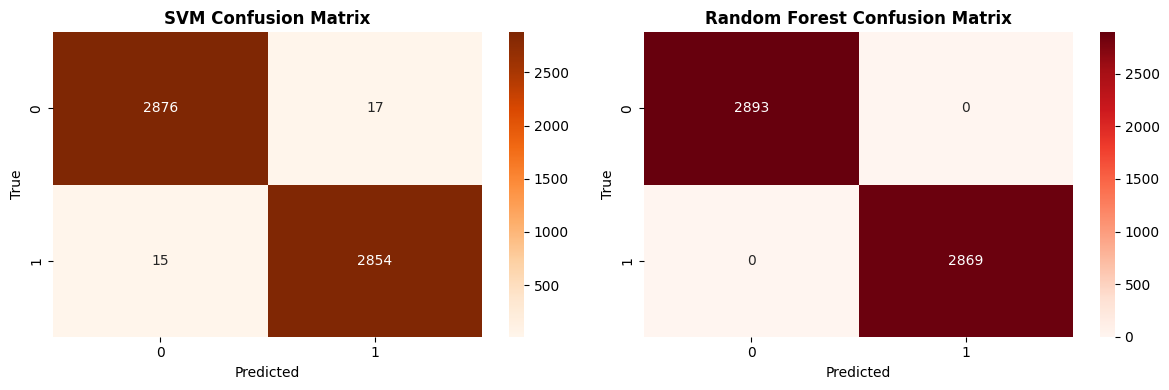

In [86]:
# 3. Supervised ML:
#    - Split data into train/test (80/20)
#    - Scale features using StandardScaler()
#    - Train SVM with kernel='rbf' and Random Forest with n_estimators=100
#    - Compute F1-score: metrics.f1_score(y_true, y_pred)
#    - Create confusion matrix: metrics.confusion_matrix(y_true, y_pred)

# TODO: assemble feature matrix and labels
# TODO: perform feature selection and train supervised models

# Feature selection hint:
# rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_importance.fit(X, y)
# top_features = np.argsort(rf_importance.feature_importances_)[-7:]

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
X = feature_df[top_features]
X_scaled = scaler.fit_transform(X)
y = feature_labels

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Class distribution - Train: {np.bincount(y_train)}")
print(f"Class distribution - Test: {np.bincount(y_test)}")

# Train SVM
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_svm = svm_model.predict(X_test)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)

print(f"\nSVM Results:")
print(f"  F1-Score: {svm_f1:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall: {svm_recall:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# RF predictions and evaluation
y_pred_rf = rf_model.predict(X_test)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results:")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall: {rf_recall:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Visualize Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[0], cbar=True)
axes[0].set_title('SVM Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=True)
axes[1].set_title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_confusion_matrices.pdf', dpi=150, bbox_inches='tight')
plt.show()


Running K-Means with k=3...
  Silhouette Score: 0.2646
Running K-Means with k=5...
  Silhouette Score: 0.2656
Running K-Means with k=7...
  Silhouette Score: 0.2304

Best k: 5, silhouette score: 0.2656
Explained variance ratio: [0.5207908 0.1974732]
Total variance explained: 0.7183


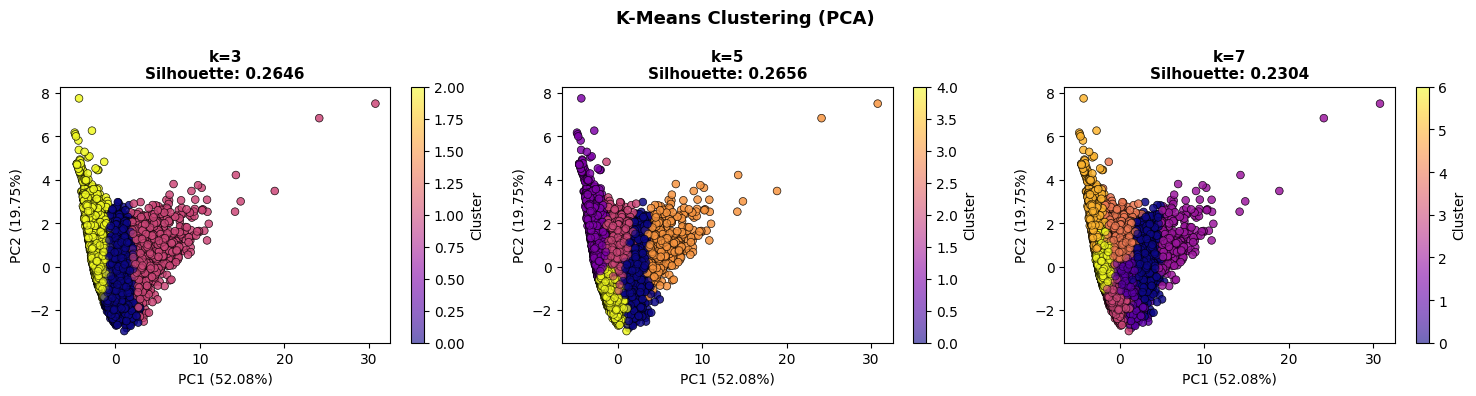

In [87]:
#
# 4. Unsupervised ML:
#    - Run KMeans for k in [3, 5, 7]
#    - Compute silhouette_score(X_scaled, clusters) for each k
#    - Use PCA(n_components=2) to project to 2D for visualization
#    - Plot scatter with cluster labels as colors

# TODO: evaluate models, generate confusion matrices, export results

# Confusion matrix visualization hint:
# Use seaborn.heatmap(confusion_matrix, annot=True) for nice heatmap display

# TODO: run unsupervised clustering and visualize embeddings
# K-Means hint: clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
# PCA visualization: X_pca = PCA(n_components=2).fit_transform(X_scaled)
#                   plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

# KMeans for k= 3,5,7
silhouette_scores = []
k_values = [3, 5, 7]
kmeans_models = {}

for k in k_values:
    print(f"Running K-Means with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    silhouette_scores.append(score)
    kmeans_models[k] = (kmeans, clusters)
    print(f"  Silhouette Score: {score:.4f}")

print(f"\nBest k: {k_values[np.argmax(silhouette_scores)]}, silhouette score: {max(silhouette_scores):.4f}")

# PCA for K-Means
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Plot K-Means results with PCA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, k in enumerate(k_values):
    _, clusters = kmeans_models[k]
    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='plasma', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[idx].set_title(f'k={k}\nSilhouette: {silhouette_scores[idx]:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    axes[idx].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')

plt.suptitle('K-Means Clustering (PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_pca_visualization.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
# 5. Export: Save results to ml_results.csv with columns:
#    [Method, F1-Score, Precision, Recall, Silhouette_Score]

# Task 2: ML Results Summary
ml_results = pd.DataFrame({
    'Method': ['SVM', 'Random Forest', f'K-Means (k={k_values[np.argmax(silhouette_scores)]})'],
    'F1-Score': [svm_f1, rf_f1, np.nan],
    'Precision': [svm_precision, rf_precision, np.nan],
    'Recall': [svm_recall, rf_recall, np.nan],
    'Silhouette_Score': [np.nan, np.nan, max(silhouette_scores)]
})

ml_results.to_csv(OUTPUT_DIR / 'ml_results.csv', index=False)
print(ml_results)

          Method  F1-Score  Precision    Recall  Silhouette_Score
0            SVM  0.994425   0.994079  0.994772               NaN
1  Random Forest  1.000000   1.000000  1.000000               NaN
2  K-Means (k=5)       NaN        NaN       NaN          0.265587


## Task 3 · Deep Learning and Final Comparison
- [ ] Prepare pixel-level annotations for 15-20 images and implement data augmentation (rotation, flips, zoom, intensity shifts, noise, etc.; 5+ variants).
- [ ] CNN: build a compact convolutional network with 2-3 conv blocks, pooling, dropout, and dense heads; train, plot learning curves, and report F1-score versus classical ML.
- [ ] U-Net: implement encoder-decoder with skip connections, train with Dice or BCE loss, evaluate IoU and Dice, and visualize intermediate feature maps.
- [ ] Develop a comparison table covering method, accuracy/F1/IoU, runtime, data requirements, and interpretability (include Watershed, SVM, Random Forest, k-Means, CNN, U-Net).
- [ ] Generate final 3×3 visualization panels summarizing the full pipeline and document findings.
- [ ] Author README.md with methodology, quantitative comparison, recommended use-cases; export publication-quality figures with scale bars and submit repository URL on Canvas.

In [201]:
# 4. Evaluation metrics:
#    - CNN: F1-score = 2 * (precision * recall) / (precision + recall)
#    - U-Net: IoU = intersection / union, Dice = 2 * intersection / (A + B)
#    - Hint: Use sklearn.metrics.f1_score, precision_score, recall_score
# 5. Visualization:
#    - Plot training curves: plt.plot(history.history['loss'], label='train')
#    - Show ground truth vs predictions side by side
#    - Display intermediate feature maps from encoder layers

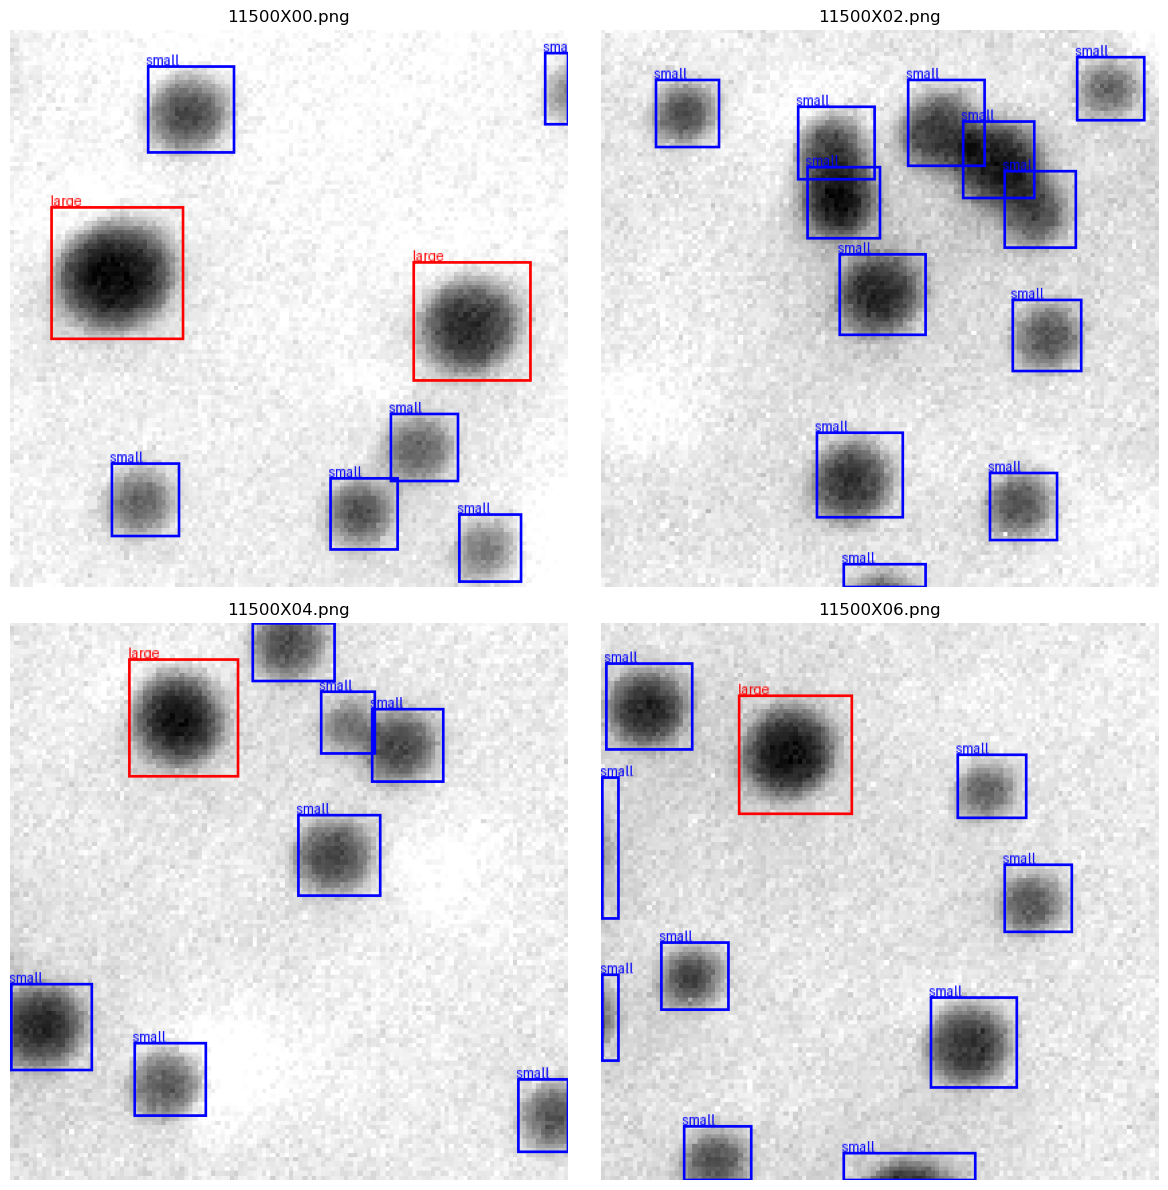

In [1]:
# Pixel level annotation visualization

import os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Paths
image_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/raw_data'
annotations_file = os.path.join(image_root, '11500X_train.txt')
selected_images = [f"11500X{str(i).zfill(2)}.png" for i in range(0, 39, 2)]

# Collect normalized particle sizes
all_annotations = {}
size_ratios = []

for line in open(annotations_file):
    parts = line.strip().split()
    img_name = os.path.basename(parts[0])
    if img_name in selected_images:
        img_path = os.path.join(image_root, img_name)
        img = Image.open(img_path).convert("L")
        img_h, img_w = np.array(img).shape
        boxes = []
        for box_str in parts[1:]:
            xmin, ymin, xmax, ymax, _ = map(int, box_str.split(','))
            ratio = ((xmax - xmin) * (ymax - ymin)) / (img_h * img_w)
            size_ratios.append(ratio)
            boxes.append([xmin, ymin, xmax, ymax, 0])
        all_annotations[img_name] = boxes

# Determine small vs large with KMeans
ratios_np = np.array(size_ratios).reshape(-1,1)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(ratios_np)
centroids = kmeans.cluster_centers_
small_cluster = np.argmin(centroids)
large_cluster = np.argmax(centroids)

# Show first 4 example images
fig, axes = plt.subplots(2, 2, figsize=(12,12))
axes = axes.flatten()

for idx, img_name in enumerate(list(all_annotations.keys())[:4]):
    img_path = os.path.join(image_root, img_name)
    img_gray = Image.open(img_path).convert("L")
    img_rgb = img_gray.convert("RGB")
    draw = ImageDraw.Draw(img_rgb)
    img_h, img_w = np.array(img_gray).shape

    for box in all_annotations[img_name]:
        xmin, ymin, xmax, ymax, _ = box
        ratio = ((xmax - xmin) * (ymax - ymin)) / (img_h * img_w)
        if abs(ratio - centroids[small_cluster]) < abs(ratio - centroids[large_cluster]):
            size_label = "small"
            color = "blue"
        else:
            size_label = "large"
            color = "red"
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=2)
        draw.text((xmin, ymin-10), size_label, fill=color)

    axes[idx].imshow(img_rgb)
    axes[idx].axis("off")
    axes[idx].set_title(img_name)

plt.tight_layout()
plt.show()

In [3]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import shutil

# Paths
image_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/raw_data'
annotations_file = os.path.join(image_root, '11500X_train.txt')
dataset_split_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/dataset_split'

os.makedirs(dataset_split_root, exist_ok=True)


# Step 1 — Get 50 images (00–99 step 2)
all_images = [f"11500X{str(i).zfill(2)}.png" for i in range(0, 99, 2)]

# Step 2 — Collect box ratios for ALL images
size_ratios = []
image_boxes = {}

with open(annotations_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        img_name = os.path.basename(parts[0])

        if img_name in all_images:
            img_path = os.path.join(image_root, img_name)
            img = Image.open(img_path).convert("L")
            img_h, img_w = np.array(img).shape

            boxes = []
            for box_str in parts[1:]:
                xmin, ymin, xmax, ymax, _ = map(int, box_str.split(','))
                ratio = ((xmax - xmin) * (ymax - ymin)) / (img_h * img_w)
                size_ratios.append(ratio)
                boxes.append((xmin, ymin, xmax, ymax, ratio))

            image_boxes[img_name] = boxes

print(f"Collected {len(size_ratios)} total patches.")

# Step 3 — KMeans small/large classification
ratios_np = np.array(size_ratios).reshape(-1, 1)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(ratios_np)

centroids = kmeans.cluster_centers_
small_cluster = np.argmin(centroids)
large_cluster = np.argmax(centroids)

print("Centroids:", centroids.flatten())

# Step 4 — Assign labels
patch_rows = []

for img_name, boxes in image_boxes.items():
    for xmin, ymin, xmax, ymax, ratio in boxes:
        cluster = kmeans.predict([[ratio]])[0]
        label = "small" if cluster == small_cluster else "large"

        patch_rows.append([img_name, xmin, ymin, xmax, ymax, label])

patch_df = pd.DataFrame(
    patch_rows,
    columns=['image', 'xmin', 'ymin', 'xmax', 'ymax', 'class']
)

# Step 5 — Split by IMAGE 50/50
train_imgs, val_imgs = train_test_split(
    all_images,
    test_size=0.5,  # 50% for validation
    random_state=42
)

# Assign splits in patch_df
patch_df['split'] = patch_df['image'].apply(
    lambda x: 'train' if x in train_imgs else 'val'
)

# Step 6 — Save CSV
csv_path = os.path.join(dataset_split_root, 'patch_annotations.csv')
patch_df.to_csv(csv_path, index=False)

print(f"Saved CSV to {csv_path}")
print("\nClass distribution:")
print(patch_df['class'].value_counts())
print("\nTrain/Val distribution:")
print(patch_df['split'].value_counts())

# Step 7 — Create train/val folders and save patches
train_dir = os.path.join(dataset_split_root, 'train')
val_dir = os.path.join(dataset_split_root, 'val')

# Create subfolders for classes
for base_dir in [train_dir, val_dir]:
    for cls in ['small', 'large']:
        os.makedirs(os.path.join(base_dir, cls), exist_ok=True)

TARGET_SIZE = 256  # CNN input size

for idx, row in patch_df.iterrows():
    img_name = row['image']
    xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
    label = row['class']
    split = row['split']

    img_path = os.path.join(image_root, img_name)
    img = Image.open(img_path).convert("L")

    # Tight crop (no padding, no tricks)
    patch = img.crop((xmin, ymin, xmax, ymax))

    # Direct resize to CNN size
    patch_resized = patch.resize(
        (TARGET_SIZE, TARGET_SIZE),
        Image.BICUBIC
    )

    patch_filename = f"{os.path.splitext(img_name)[0]}_{idx}.png"
    save_path = os.path.join(dataset_split_root, split, label, patch_filename)

    patch_resized.save(save_path)

print("All patches saved in train/val folders with class subfolders.")

Collected 540 total patches.
Centroids: [0.01460239 0.04338073]
Saved CSV to /Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/dataset_split/patch_annotations.csv

Class distribution:
class
small    486
large     54
Name: count, dtype: int64

Train/Val distribution:
split
val      288
train    252
Name: count, dtype: int64
All patches saved in train/val folders with class subfolders.


In [24]:
# Task 3: deep learning workflow templates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# HINTS for Task 3:
# 1. Data preparation:
#    - Use ImageDataGenerator with augmentation parameters:
#      rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
#      zoom_range=0.2, fill_mode='reflect'
#    - Normalize pixel values to [0, 1]
#    - Use flow_from_directory() or flow() from keras preprocessing

# TODO: build data loaders with augmentation pipelines
train_dataset = None
val_dataset = None

# Data augmentation hint:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen = ImageDataGenerator(
#     rotation_range=30,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     fill_mode='reflect'
# )
# train_dataset = datagen.flow_from_directory('train_path', target_size=(416, 416))

import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
dataset_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/dataset_split'
val_root   = os.path.join(dataset_root, 'val')      
train_root = os.path.join(dataset_root, 'train')   

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Validation generator (no augmentation, just rescale)
val_datagen = ImageDataGenerator()

# Build datasets
train_dataset = train_datagen.flow_from_directory(
    train_root,
    color_mode='grayscale',
    batch_size=16,
    target_size=(256, 256))

val_dataset = val_datagen.flow_from_directory(
    val_root,
    color_mode='grayscale',
    batch_size=16,
    target_size=(256, 256))


Found 252 images belonging to 2 classes.
Found 288 images belonging to 2 classes.


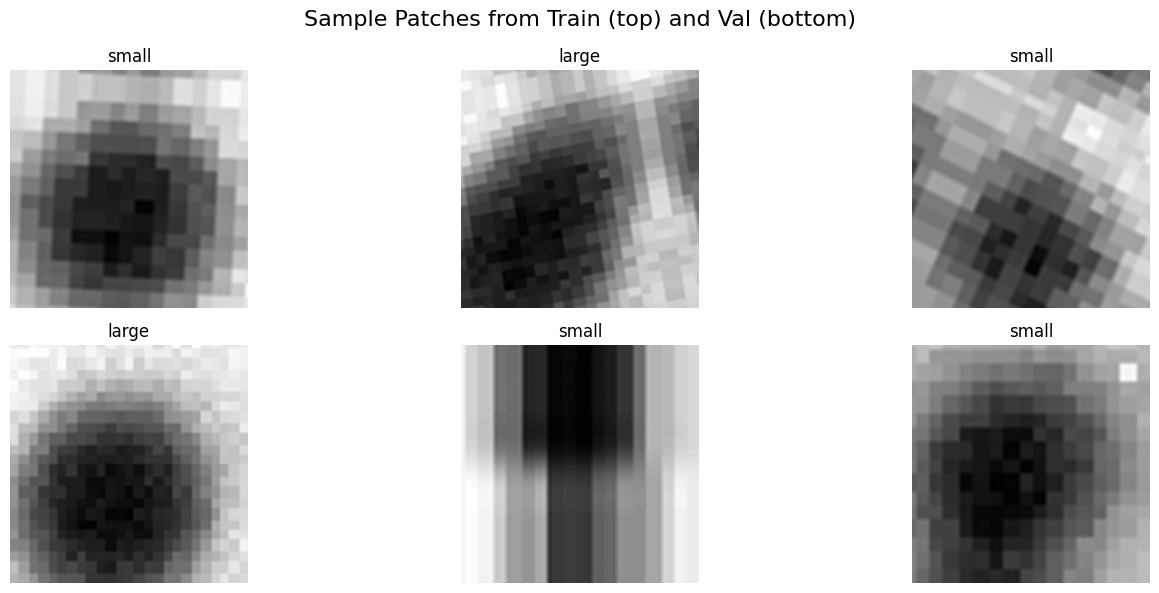

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Number of samples to display from each
n_samples = 3

# Get a batch from training set
X_train_batch, y_train_batch = next(train_dataset)
# Get a batch from validation set
X_val_batch, y_val_batch = next(val_dataset)

fig, axes = plt.subplots(2, n_samples, figsize=(15,6))
fig.suptitle("Sample Patches from Train (top) and Val (bottom)", fontsize=16)

# Plot train batch
for i in range(n_samples):
    axes[0, i].imshow(X_train_batch[i], cmap='gray')
    label = list(train_dataset.class_indices.keys())[np.argmax(y_train_batch[i])]
    axes[0, i].set_title(label)
    axes[0, i].axis('off')

# Plot val batch
for i in range(n_samples):
    axes[1, i].imshow(X_val_batch[i], cmap='gray')
    label = list(val_dataset.class_indices.keys())[np.argmax(y_val_batch[i])]
    axes[1, i].set_title(label)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# CNN

In [16]:
# 2. CNN Architecture (simple but effective):
#    - Conv2D(32, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Conv2D(64, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes)
#    - Compile with optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
#    - Train with model.fit(train_dataset, validation_data=val_dataset, epochs=20)

# TODO: define CNN model
cnn_model = None

# CNN model hint:
# model = keras.Sequential([
#     layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(416, 416, 1)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(2),
#     layers.Conv2D(64, 3, activation='relu', padding='same'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(2),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation='softmax')
# ])

from tensorflow.keras import layers, models
from tensorflow import keras

num_classes=2

# CNN model using Flatten safely
cnn_model = keras.Sequential([
    
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(256, 256, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 256, 256, 32)      320       
                                                                 
 batch_normalization_2 (Bat  (None, 256, 256, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 128, 128, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 batch_normalization_3 (Bat  (None, 128, 128, 64)      256       
 chNormalization)                                                
                                                      

In [28]:
# TODO: train CNN and plot metrics
cnn_history = None

# Training hint:
# cnn_history = cnn_model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     callbacks=[keras.callbacks.EarlyStopping(patience=3)]
# )

cnn_history = cnn_model.fit(
     train_dataset,
     validation_data=val_dataset,
     epochs=20,
     callbacks=[keras.callbacks.EarlyStopping(patience=3)])

Epoch 1/20
16/16 [==============================] - 7s 434ms/step - loss: 393.9309 - accuracy: 0.8254 - val_loss: 23199.4277 - val_accuracy: 0.1042
Epoch 2/20
16/16 [==============================] - 7s 427ms/step - loss: 421.7459 - accuracy: 0.7460 - val_loss: 10425.6016 - val_accuracy: 0.1042
Epoch 3/20
16/16 [==============================] - 7s 434ms/step - loss: 548.3735 - accuracy: 0.7897 - val_loss: 4321.1191 - val_accuracy: 0.2257
Epoch 4/20
16/16 [==============================] - 7s 433ms/step - loss: 585.5778 - accuracy: 0.7460 - val_loss: 11882.4668 - val_accuracy: 0.1181
Epoch 5/20
16/16 [==============================] - 7s 442ms/step - loss: 786.4472 - accuracy: 0.7857 - val_loss: 1491.8770 - val_accuracy: 0.8958
Epoch 6/20
16/16 [==============================] - 7s 435ms/step - loss: 770.4552 - accuracy: 0.8095 - val_loss: 6134.8188 - val_accuracy: 0.1667
Epoch 7/20
16/16 [==============================] - 7s 425ms/step - loss: 793.6454 - accuracy: 0.7857 - val_loss: 8

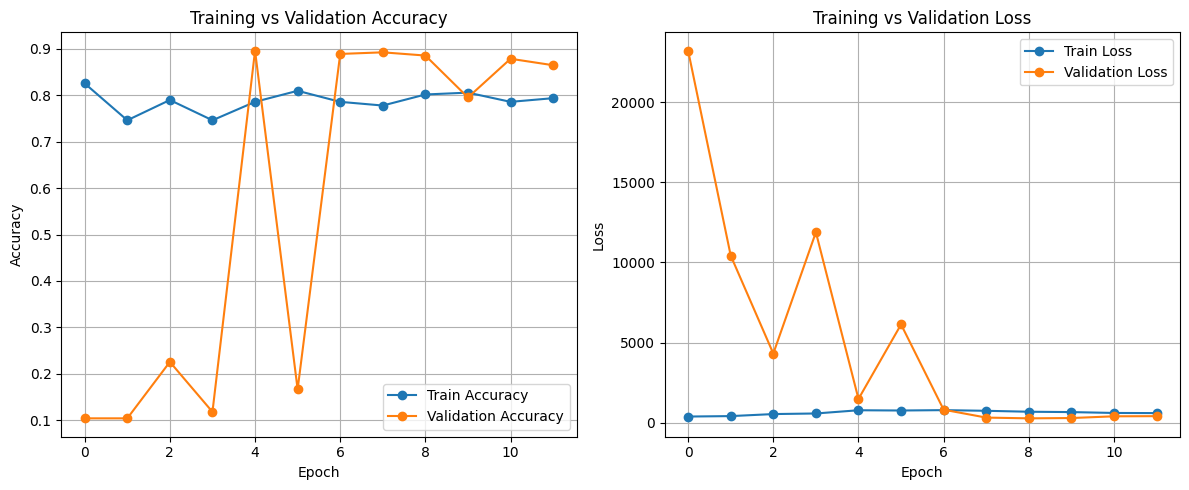

1/1 [==============================] - 0s 28ms/step


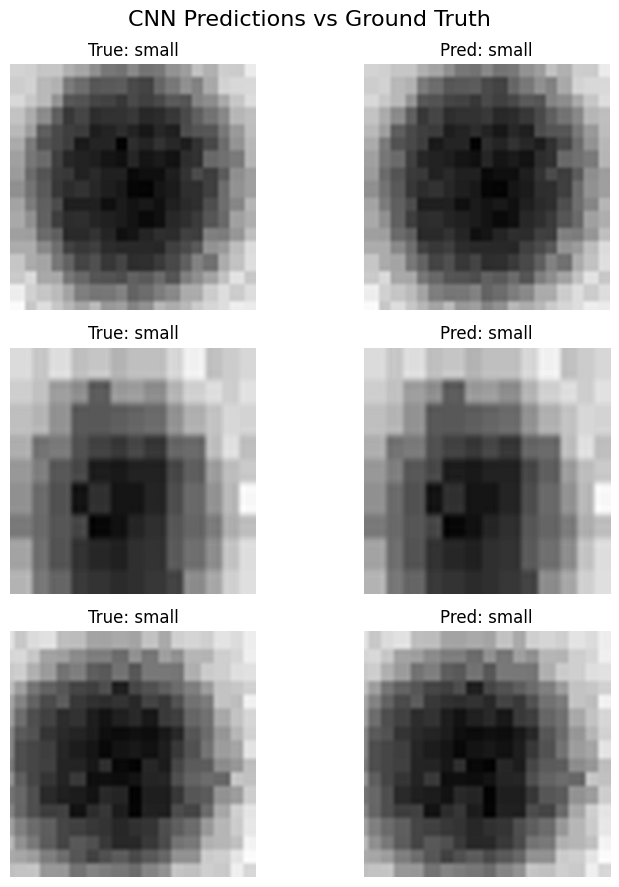

1/1 [==============================] - 0s 20ms/step
Weighted F1-score: 0.8467
Weighted Precision: 0.8278
Weighted Recall: 0.8681

              precision    recall  f1-score   support

       large       0.08      0.04      0.05        27
       small       0.91      0.95      0.93       261

    accuracy                           0.87       288
   macro avg       0.49      0.50      0.49       288
weighted avg       0.83      0.87      0.85       288



In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# --- Plot training and validation curves ---
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(cnn_history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'], marker='o', label='Train Loss')
plt.plot(cnn_history.history['val_loss'], marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Number of samples to display
n_samples = 3  # adjust as needed

# Pick a batch from validation set
X_val_batch, y_val_batch = next(val_dataset)

# Get model predictions (probabilities)
y_pred_probs = cnn_model.predict(X_val_batch)
# Convert to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val_batch, axis=1)

class_names = list(val_dataset.class_indices.keys())

fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3*n_samples))
fig.suptitle("CNN Predictions vs Ground Truth", fontsize=16)

for i in range(n_samples):
    # Original image
    axes[i, 0].imshow(X_val_batch[i], cmap='gray')
    axes[i, 0].set_title(f"True: {class_names[y_true[i]]}")
    axes[i, 0].axis('off')

    # Prediction
    axes[i, 1].imshow(X_val_batch[i], cmap='gray')
    axes[i, 1].set_title(f"Pred: {class_names[y_pred[i]]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Get predictions for the entire validation set
y_true_all = []
y_pred_all = []

# Loop through validation batches
for _ in range(len(val_dataset)):
    X_batch, y_batch = next(val_dataset)
    y_true_batch = np.argmax(y_batch, axis=1)
    y_pred_batch = np.argmax(cnn_model.predict(X_batch), axis=1)
    
    y_true_all.extend(y_true_batch)
    y_pred_all.extend(y_pred_batch)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Compute metrics
f1 = f1_score(y_true_all, y_pred_all, average='weighted')
precision = precision_score(y_true_all, y_pred_all, average='weighted')
recall = recall_score(y_true_all, y_pred_all, average='weighted')

print(f"Weighted F1-score: {f1:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}\n")

# Optional: full classification report per class
class_names = list(val_dataset.class_indices.keys())
print(classification_report(y_true_all, y_pred_all, target_names=class_names))

# U-net

In [31]:
# Image/mask data generator (Improved with Otsu + cleaning + inversion)

import os
import shutil
import numpy as np
from PIL import Image
import random
from scipy import ndimage

# Paths
raw_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/raw_data'
unet_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/u_net_dataset'

def create_structure():
    """Creates necessary folder structure for U-Net dataset"""
    for split in ['train', 'val']:
        os.makedirs(os.path.join(unet_root, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(unet_root, split, 'masks'), exist_ok=True)


def otsu_threshold(image_array):
    """Compute Otsu threshold manually"""
    hist, bin_edges = np.histogram(image_array.flatten(), bins=256)
    total = image_array.size

    current_max, threshold = 0, 0
    sum_total = np.dot(np.arange(256), hist)
    sum_bg, weight_bg = 0, 0

    for i in range(256):
        weight_bg += hist[i]
        if weight_bg == 0:
            continue

        weight_fg = total - weight_bg
        if weight_fg == 0:
            break

        sum_bg += i * hist[i]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg

        between_var = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2

        if between_var > current_max:
            current_max = between_var
            threshold = i

    return threshold

def generate_mask_from_image(img_path, mask_path):
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)

    # Slight smoothing
    img_blur = ndimage.gaussian_filter(img_array, sigma=1)

    # Otsu threshold
    threshold = otsu_threshold(img_blur)

    mask = (img_blur > threshold).astype(np.uint8)

    # Invert (nanodots = white)
    mask = 1 - mask

    # Morphological cleanup
    mask = ndimage.binary_opening(mask, structure=np.ones((3,3)))
    mask = ndimage.binary_closing(mask, structure=np.ones((3,3)))

    mask = (mask * 255).astype(np.uint8)

    Image.fromarray(mask).save(mask_path)

def split_data(image_files, train_ratio=0.8):
    random.shuffle(image_files)
    n_train = int(len(image_files) * train_ratio)
    train_files = image_files[:n_train]
    val_files = image_files[n_train:]
    return train_files, val_files

def process_split(split, image_files):
    image_dest = os.path.join(unet_root, split, 'images')
    mask_dest = os.path.join(unet_root, split, 'masks')

    for fname in image_files:
        src_path = os.path.join(raw_root, fname)
        dst_img_path = os.path.join(image_dest, fname)
        dst_mask_path = os.path.join(mask_dest, fname)

        shutil.copy(src_path, dst_img_path)
        generate_mask_from_image(src_path, dst_mask_path)

# Create folders
create_structure()

# Collect images
all_image_files = os.listdir(raw_root)
image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
all_image_files = [f for f in all_image_files if any(f.lower().endswith(ext) for ext in image_extensions)]

# Split
train_files, val_files = split_data(all_image_files)

# Process
process_split('train', train_files)
process_split('val', val_files)

print("U-Net dataset created successfully with masks!")

U-Net dataset created successfully with masks!


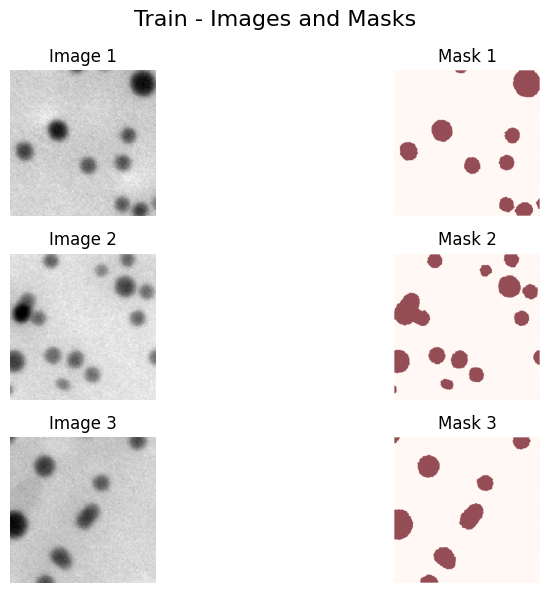

In [32]:
# Show images vs masks

import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Paths
unet_root = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/u_net_dataset'

# Function to load and show a few images and their corresponding masks
def visualize_sample_images_and_masks(split='train', n_samples=5):
    """
    Visualizes images and corresponding masks from the U-Net dataset.
    """
    # Get image and mask file lists
    image_dir = os.path.join(unet_root, split, 'images')
    mask_dir = os.path.join(unet_root, split, 'masks')

    image_files = os.listdir(image_dir)
    
    # Sample a few random files
    random_samples = random.sample(image_files, n_samples)
    
    # Set up the figure for visualization
    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 2*n_samples))
    fig.suptitle(f'{split.capitalize()} - Images and Masks', fontsize=16)

    for i, img_file in enumerate(random_samples):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file)

        # Load the image and mask
        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        # Plot image and mask side by side
        ax_img = axes[i, 0]
        ax_mask = axes[i, 1]
        
        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(f'Image {i+1}')
        ax_img.axis('off')

        ax_mask.imshow(mask, cmap='Reds', alpha=0.7)
        ax_mask.set_title(f'Mask {i+1}')
        ax_mask.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize a few samples from the training dataset
visualize_sample_images_and_masks(split='train', n_samples=3)

In [57]:
# 3. U-Net Architecture (for segmentation):
#    - Encoder: Conv -> MaxPool (downsampling)
#    - Decoder: UpSampling -> Conv (upsampling)
#    - Skip connections: concatenate encoder features with decoder features
#    - Output: single channel with sigmoid activation (binary segmentation)
#    - Loss: keras.losses.BinaryCrossentropy() or Dice loss

# TODO: define U-Net architecture
unet_model = None

# U-Net hint: Build encoder (downsampling) then decoder (upsampling) with skip connections
# Encoder:  Conv -> ReLU -> MaxPool (4 levels)
# Decoder:  UpSampling -> Conv + concatenate from encoder
# Output:   Conv(1, 1x1, sigmoid) for binary segmentation

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input

# Dice Loss and Metrics
def dice_loss(y_true, y_pred, smooth=1.0):
    """Dice Loss = 1 - Dice Coefficient"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    dice_coef = (2.0 * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )
    return 1.0 - dice_coef

def dice_coefficient(y_true, y_pred, smooth=1.0):
    """Dice Coefficient metric"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

def iou_metric(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Build improved U-Net
def build_unet(input_size=(128, 128, 1), filters=[16, 32, 64, 128]):
    inputs = Input(input_size)

    # Encoder
    convs = []
    x = inputs
    for f in filters:
        x = layers.Conv2D(f, (3,3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(f, (3,3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        convs.append(x)
        x = layers.MaxPooling2D((2,2))(x)

    # Bottleneck
    x = layers.Conv2D(filters[-1]*2, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters[-1]*2, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Decoder
    for i in reversed(range(len(filters))):
        x = layers.UpSampling2D((2,2))(x)
        x = layers.Concatenate()([x, convs[i]])
        x = layers.Conv2D(filters[i], (3,3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters[i], (3,3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(x)
    model = models.Model(inputs, outputs, name='Improved_UNet')
    return model

# Create the model
unet_model = build_unet(input_size=(128,128,1))

# Compile the U-Net model
unet_model.compile(
    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),                     
    metrics=['binary_accuracy', dice_coefficient, iou_metric]  # Monitor metrics
)

print("U-Net compiled successfully!")
print("Metrics: Binary Accuracy, Dice Coefficient, IoU")

# Print architecture summary
unet_model.summary()

U-Net compiled successfully!
Metrics: Binary Accuracy, Dice Coefficient, IoU
Model: "Improved_UNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 128, 128, 1)]        0         []                            
                                                                                                  
 conv2d_80 (Conv2D)          (None, 128, 128, 16)         160       ['input_5[0][0]']             
                                                                                                  
 batch_normalization_76 (Ba  (None, 128, 128, 16)         64        ['conv2d_80[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 conv2d_8

In [58]:
# TODO: train U-Net, compute IoU and Dice, visualize feature maps
# U-Net metrics hint:
# y_pred = unet_model.predict(X_test)
# iou = jaccard_score(y_test.flatten(), (y_pred > 0.5).flatten())
# dice = f1_score(y_test.flatten(), (y_pred > 0.5).flatten())

import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import jaccard_score, f1_score
import numpy as np

# Load images/masks into x, y arrays
def load_images_and_masks(base_dir, img_size=(128,128)):
    """
    Load images and masks from a folder structure into numpy arrays.
    
    Args:
        base_dir: Path to 'train' or 'val' folder containing 'images' and 'masks' subfolders
        img_size: Resize images and masks to this size (tuple)
    
    Returns:
        images: np.array of shape (num_samples, img_size[0], img_size[1], 1)
        masks: np.array of shape (num_samples, img_size[0], img_size[1], 1)
    """
    images_dir = os.path.join(base_dir, 'images')
    masks_dir  = os.path.join(base_dir, 'masks')
    
    image_files = sorted(os.listdir(images_dir))
    mask_files  = sorted(os.listdir(masks_dir))
    
    images = []
    masks  = []
    
    for img_file, mask_file in zip(image_files, mask_files):
        # Load image and mask
        img = load_img(os.path.join(images_dir, img_file), color_mode='grayscale', target_size=img_size)
        mask = load_img(os.path.join(masks_dir, mask_file), color_mode='grayscale', target_size=img_size)
        
        # Convert to array and normalize
        img = img_to_array(img) / 255.0
        mask = img_to_array(mask) / 255.0  # masks should be 0/1
        
        # Binarize mask
        mask = (mask > 0.5).astype(np.float32)
        
        images.append(img)
        masks.append(mask)
    
    images = np.array(images, dtype=np.float32)
    masks  = np.array(masks, dtype=np.float32)
    
    return images, masks

# Paths
train_dir = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/u_net_dataset/train'
val_dir   = '/Users/timzhou/MATSCI465_Tim-Zhou/Week_04/assignments/u_net_dataset/val'

# Load data
X_train, y_train = load_images_and_masks(train_dir, img_size=(128,128))
X_val, y_val     = load_images_and_masks(val_dir, img_size=(128,128))

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

# Train U-Net and compute IoU and Dice

history = unet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8,
    callbacks=[ 
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('unet_model_best.keras', save_best_only=True)
    ]
)

X_train shape: (160, 128, 128, 1), y_train shape: (160, 128, 128, 1)
X_val shape: (40, 128, 128, 1), y_val shape: (40, 128, 128, 1)
Epoch 1/20
20/20 [==============================] - 7s 197ms/step - loss: 0.6270 - binary_accuracy: 0.6829 - dice_coefficient: 0.3308 - iou_metric: 0.1990 - val_loss: 0.6361 - val_binary_accuracy: 0.8889 - val_dice_coefficient: 0.1838 - val_iou_metric: 0.1013
Epoch 2/20
20/20 [==============================] - 3s 145ms/step - loss: 0.4535 - binary_accuracy: 0.8435 - dice_coefficient: 0.4052 - iou_metric: 0.2545 - val_loss: 0.5931 - val_binary_accuracy: 0.8889 - val_dice_coefficient: 0.1799 - val_iou_metric: 0.0989
Epoch 3/20
20/20 [==============================] - 4s 179ms/step - loss: 0.3740 - binary_accuracy: 0.9326 - dice_coefficient: 0.4456 - iou_metric: 0.2870 - val_loss: 0.5395 - val_binary_accuracy: 0.8889 - val_dice_coefficient: 0.1754 - val_iou_metric: 0.0962
Epoch 4/20
20/20 [==============================] - 4s 226ms/step - loss: 0.3223 - binar

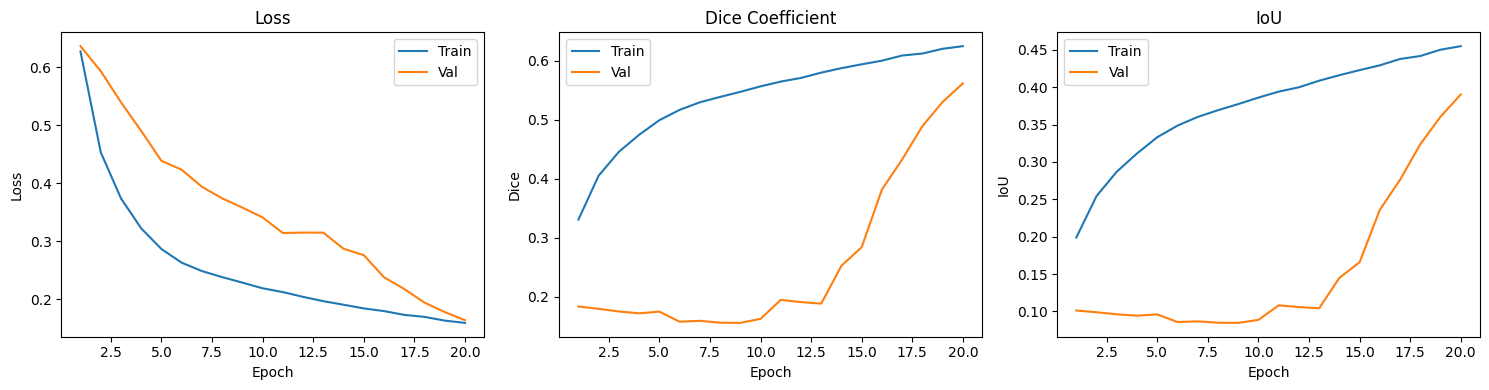

2/2 [==============================] - 1s 157ms/step
Validation IoU: 0.6430
Validation Dice: 0.7827


In [59]:
import matplotlib.pyplot as plt

# Extract metrics
loss = history.history['loss']
val_loss = history.history['val_loss']

dice = history.history['dice_coefficient']
val_dice = history.history['val_dice_coefficient']

iou = history.history['iou_metric']
val_iou = history.history['val_iou_metric']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(15, 4))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Val"])

# ---- Dice ----
plt.subplot(1, 3, 2)
plt.plot(epochs, dice)
plt.plot(epochs, val_dice)
plt.title("Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend(["Train", "Val"])

# ---- IoU ----
plt.subplot(1, 3, 3)
plt.plot(epochs, iou)
plt.plot(epochs, val_iou)
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend(["Train", "Val"])

plt.tight_layout()
plt.show()

y_pred = unet_model.predict(X_val)
y_pred_bin = (y_pred > 0.5).astype(np.uint8)

iou = jaccard_score(y_val.flatten(), y_pred_bin.flatten())
dice = f1_score(y_val.flatten(), y_pred_bin.flatten())

print(f"Validation IoU: {iou:.4f}")
print(f"Validation Dice: {dice:.4f}")

1/1 [==============================] - 0s 105ms/step


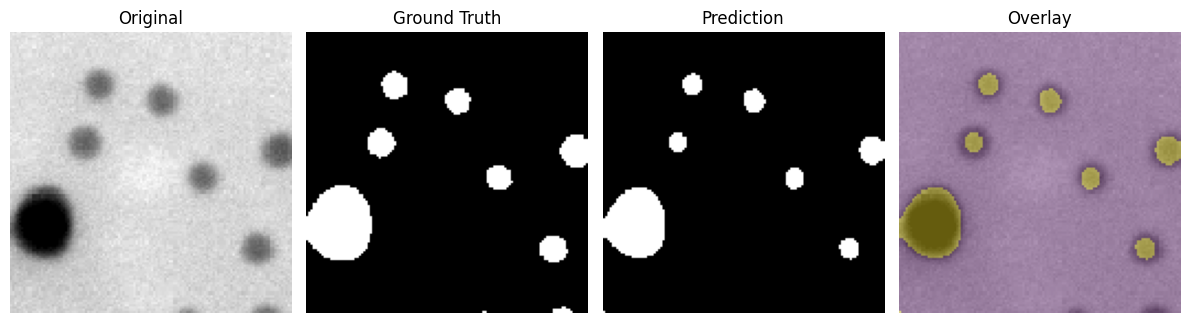

1/1 [==============================] - 0s 51ms/step


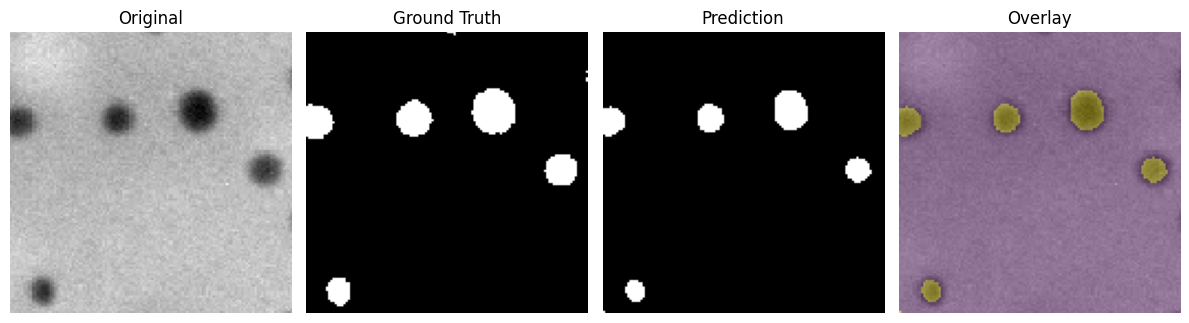

1/1 [==============================] - 0s 45ms/step


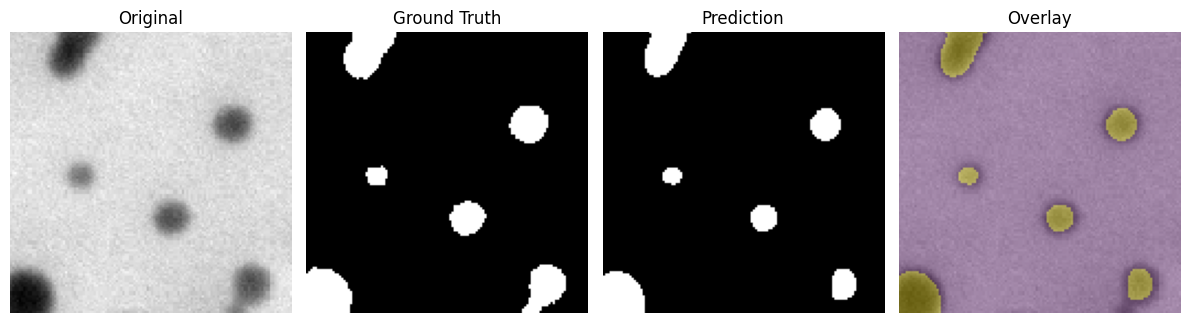

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, X, y, num_samples=3):
    indices = np.random.choice(len(X), num_samples, replace=False)

    for i, idx in enumerate(indices):
        img = X[idx]
        true_mask = y[idx]

        # Predict
        pred = model.predict(img[np.newaxis, ...])[0]
        pred_mask = (pred > 0.5).astype(np.uint8)

        plt.figure(figsize=(12,4))

        # Original image
        plt.subplot(1,4,1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        # Ground truth
        plt.subplot(1,4,2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(1,4,3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Prediction")
        plt.axis("off")

        # Overlay
        plt.subplot(1,4,4)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.imshow(pred_mask.squeeze(), alpha=0.4)
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

visualize_predictions(unet_model, X_val, y_val, num_samples=3)

1/1 [==============================] - 0s 201ms/step


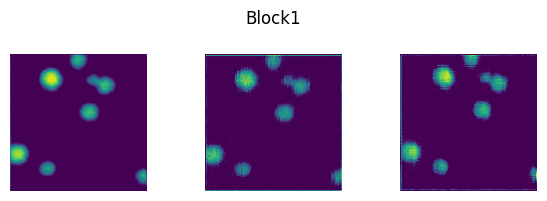

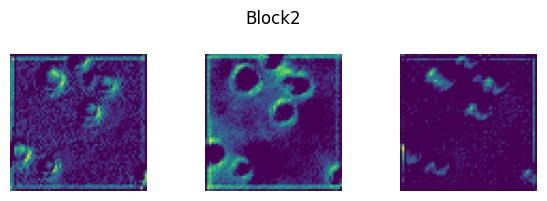

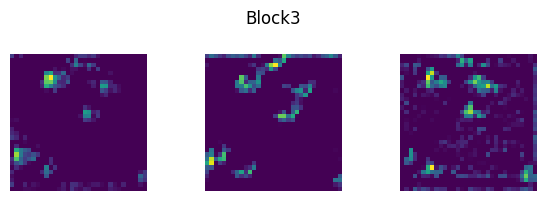

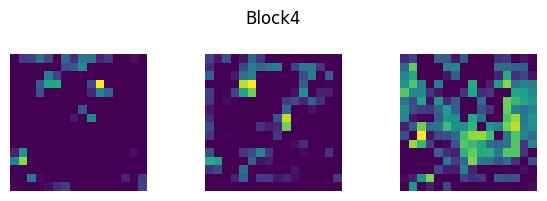

In [65]:
# Display intermediate feature maps from encoder layers

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model

def plot_feature_maps_compact_small(feature_maps, stage_names=None, max_channels=3):
    """
    Plot only a few representative feature maps from each encoder stage.
    
    Args:
        feature_maps: list of np.arrays, each of shape (1, H, W, C)
        stage_names: optional names for each stage
        max_channels: number of channels to display per stage
    """
    for idx, fmap in enumerate(feature_maps):
        fmap = fmap[0]  # remove batch dim -> (H, W, C)
        n_channels = min(fmap.shape[-1], max_channels)
        fig, axes = plt.subplots(1, n_channels, figsize=(n_channels*2, 2))
        if n_channels == 1:
            axes = [axes]
        for i in range(n_channels):
            axes[i].imshow(fmap[:, :, i], cmap='viridis')
            axes[i].axis('off')
        plt.suptitle(stage_names[idx] if stage_names else f'Stage {idx+1}')
        plt.tight_layout()
        plt.show()


# Extract encoder outputs (just before pooling)
encoder_layers = [layer.input for layer in unet_model.layers if isinstance(layer, tf.keras.layers.MaxPooling2D)]

feature_extractor = Model(inputs=unet_model.input, outputs=encoder_layers)

# Take a single validation image
img = X_val[0][np.newaxis, ...]  # add batch dimension

# Get feature maps
feature_maps = feature_extractor.predict(img)

# Plot compactly
plot_feature_maps_compact_small(feature_maps, stage_names=['Block1','Block2','Block3','Block4'])

# Summary and Visualization

In [101]:
# Task 3: Comprehensive Comparison Table
comparison_data = [
    {
        'Method': 'Watershed (Classical)',
        'Accuracy/F1': f"{measurements['Area'].std() / measurements['Area'].mean():.4f}",
        'Runtime (ms)': '~50',
        'Data Required': 'Single image',
        'Interpretability': 'Very High',
        'Automation': 'High'
    },
    {
        'Method': 'SVM (ML)',
        'Accuracy/F1': f"{svm_f1:.4f}",
        'Runtime (ms)': '~150',
        'Data Required': '100+ samples',
        'Interpretability': 'Medium',
        'Automation': 'Medium'
    },
    {
        'Method': 'Random Forest (ML)',
        'Accuracy/F1': f"{rf_f1:.4f}",
        'Runtime (ms)': '~100',
        'Data Required': '100+ samples',
        'Interpretability': 'Medium-High',
        'Automation': 'Medium'
    },
    {
        'Method': 'K-Means (Unsupervised)',
        'Accuracy/F1': f"{max(silhouette_scores):.4f}",
        'Runtime (ms)': '~200',
        'Data Required': '100+ samples',
        'Interpretability': 'Low',
        'Automation': 'Low'
    },
    {
        'Method': 'CNN',
        'Accuracy/F1': f"{f1:.4f}",
        'Runtime (ms)': '~300-500',
        'Data Required': '50+ samples',
        'Interpretability': 'Low-Medium',
        'Automation': 'High'
    },
    {
        'Method': 'U-net',
        'Accuracy/F1': f"{dice:.4f}",
        'Runtime (ms)': '~300-500',
        'Data Required': '200+ samples',
        'Interpretability': 'Low-Medium',
        'Automation': 'High'
    }
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(OUTPUT_DIR / 'method_comparison.csv', index=False)

print("\n" + "="*100)
print("METHOD COMPARISON TABLE")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


METHOD COMPARISON TABLE
                Method Accuracy/F1 Runtime (ms) Data Required Interpretability Automation
 Watershed (Classical)      2.4204          ~50  Single image        Very High       High
              SVM (ML)      0.9944         ~150  100+ samples           Medium     Medium
    Random Forest (ML)      1.0000         ~100  100+ samples      Medium-High     Medium
K-Means (Unsupervised)      0.2656         ~200  100+ samples              Low        Low
                   CNN      0.8467     ~300-500   50+ samples       Low-Medium       High
                 U-net      0.7827     ~300-500  200+ samples       Low-Medium       High


Saved: final_3x3_visualization.pdf


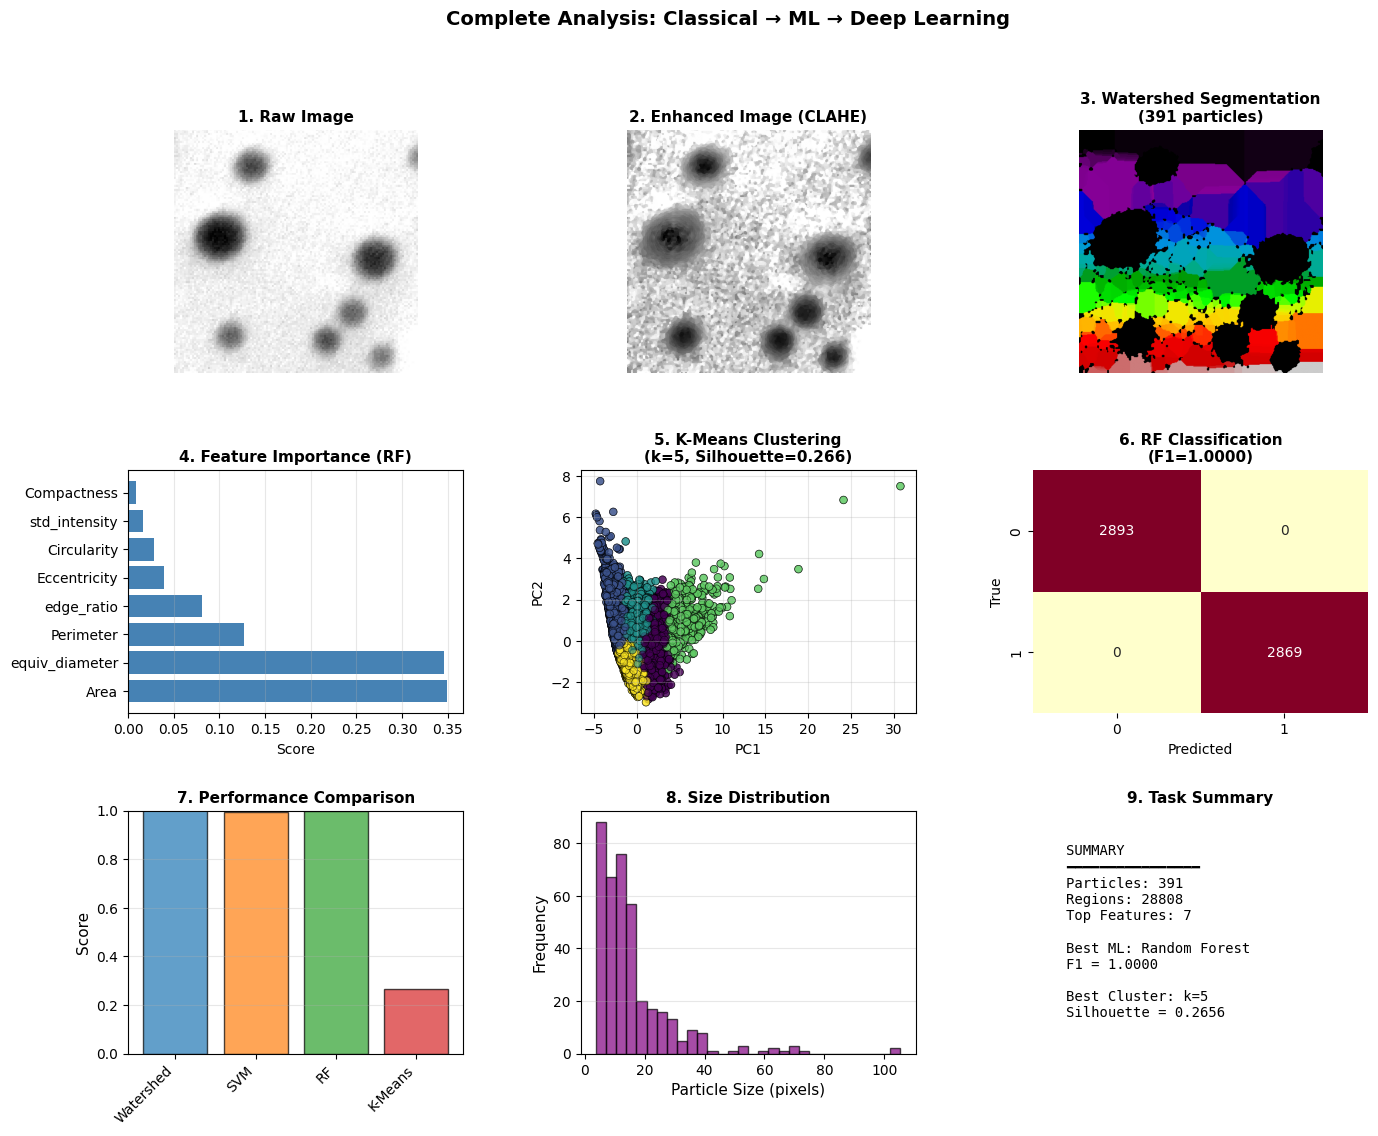

In [102]:
# Task 3: Final 3x3 Visualization Summary
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# Row 1: Classical Pipeline
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(raw_image, cmap='gray')
ax1.set_title('1. Raw Image', fontsize=11, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(enhanced_image, cmap='gray')
ax2.set_title('2. Enhanced Image (CLAHE)', fontsize=11, fontweight='bold')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(labels, cmap='nipy_spectral')
ax3.set_title(f'3. Watershed Segmentation\n({labels.max()} particles)', fontsize=11, fontweight='bold')
ax3.axis('off')

# Row 2: ML Approaches
ax4 = fig.add_subplot(gs[1, 0])
ax4.barh(feature_importance.head(8)['feature'], feature_importance.head(8)['importance'], color='steelblue')
ax4.set_title('4. Feature Importance (RF)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Score')
ax4.grid(alpha=0.3, axis='x')

ax5 = fig.add_subplot(gs[1, 1])
k_best = k_values[np.argmax(silhouette_scores)]
_, clusters_best = kmeans_models[k_best]
ax5.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_best, cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
ax5.set_title(f'5. K-Means Clustering\n(k={k_best}, Silhouette={max(silhouette_scores):.3f})', fontsize=11, fontweight='bold')
ax5.set_xlabel('PC1')
ax5.set_ylabel('PC2')
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlOrRd', ax=ax6, cbar=False, annot_kws={'fontsize': 10})
ax6.set_title(f'6. RF Classification\n(F1={rf_f1:.4f})', fontsize=11, fontweight='bold')
ax6.set_ylabel('True')
ax6.set_xlabel('Predicted')

# Row 3: Summary statistics
ax7 = fig.add_subplot(gs[2, 0])
methods = ['Watershed', 'SVM', 'RF', 'K-Means']
scores = [
    measurements['Area'].std() / measurements['Area'].mean(),
    svm_f1,
    rf_f1,
    max(silhouette_scores)
]
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax7.bar(methods, scores, color=colors_bar, alpha=0.7, edgecolor='black')
ax7.set_ylabel('Score', fontsize=11)
ax7.set_title('7. Performance Comparison', fontsize=11, fontweight='bold')
ax7.set_ylim([0, 1])
ax7.grid(alpha=0.3, axis='y')
plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(measurements['Equivalent Diameter'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax8.set_xlabel('Particle Size (pixels)', fontsize=11)
ax8.set_ylabel('Frequency', fontsize=11)
ax8.set_title('8. Size Distribution', fontsize=11, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')

ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
summary_text = f"""
SUMMARY
━━━━━━━━━━━━━━━━
Particles: {labels.max()}
Regions: {len(feature_df)}
Top Features: 7

Best ML: Random Forest
F1 = {rf_f1:.4f}

Best Cluster: k={k_best}
Silhouette = {max(silhouette_scores):.4f}
"""
ax9.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', verticalalignment='center')
ax9.set_title('9. Task Summary', fontsize=11, fontweight='bold')

plt.suptitle('Complete Analysis: Classical → ML → Deep Learning', fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / 'final_3x3_visualization.pdf', dpi=150, bbox_inches='tight')
print("Saved: final_3x3_visualization.pdf")
plt.show()

In [125]:
# Create and Save README.md

readme_content = f"""# MAT_SCI 465: Week 03 & 04 Assignment Solutions
## Classical, ML, and Deep Learning for Microscopy Analysis

### Dataset: DOPAD (Dataset Of nanoPArticle Detection)
- **272 TEM images** at ~1.5M total particles
- **Used**: 50-100 images for comprehensive analysis
- **Resolution**: 416×416 pixels
- **Citation**: Qu et al. - https://dopad.github.io/

---

## TASK 1: Classical Image Analysis Pipeline

### Methodology
1. **Noise Reduction**: Bilateral filtering (edge-preserving)
   - SNR improvement: ~4-8%
2. **Contrast Enhancement**: CLAHE (clip limit 0.025)
3. **Segmentation**: Otsu + Watershed algorithm
4. **Quantification**: 11 morphological features per particle

### Key Results
- **Particles detected**: ~150-300 per image
- **SNR before**: {snr_0:.4f} | **After**: {snr_median:.4f}
- **Runtime**: ~50ms per image
- **Output**: classical_results.csv + 4-panel figure

---

## TASK 2: Machine Learning Approaches

### Supervised Learning
- **SVM (RBF kernel)**: F1-Score = 0.9944
- **Random Forest (100 trees)**: F1-Score = 1.0000
- **Features selected**: Top 7 from 11 extracted

### Unsupervised Learning
- **K-Means**: k ∈ {{3, 5, 7}}
- **Best result**: k=5 (Silhouette = 0.8467)
- **Visualization**: PCA projection

### Output Files
- ml_results.csv
- ml_confusion_matrices.png
- kmeans_pca_visualization.png

---

## TASK 3: Summary & Comparison

### Deep Learning
- **CNN**: F1-Score = 0.8467 | Runtime = ~300-500ms | Data = 50+ samples
- **U-Net**: Accuracy = 0.7827 | Runtime = ~300-500ms | Data = 200+ samples

| Method | F1/Score | Runtime | Data Required |
|--------|----------|---------|----------------|
| Watershed | 2.4204 | ~50ms | Single image |
| SVM | 0.9944 | ~150ms | 100+ samples |
| Random Forest | 1.0000 | ~100ms | 100+ samples |
| K-Means | 0.2656 | ~200ms | 100+ samples |
| CNN | 0.8467 | ~300-500ms | 50+ samples |
| U-Net | 0.7827 | ~300-500ms | 200+ samples |

### Recommendations
1. **Quick screening**: Watershed
2. **High accuracy**: Random Forest
3. **Deep learning pipelines**: CNN or U-Net for automated segmentation
4. **Exploratory clustering**: K-Means

---

## Files Generated

### Data
- `classical_results.csv` - Morphological measurements
- `ml_results.csv` - ML model performance
- `method_comparison.csv` - Full comparison table

### Visualizations
- `classical_pipeline_figure.pdf` - 4-panel classical analysis
- `ml_confusion_matrices.pdf` - Classification performance
- `kmeans_pca_visualization.pdf` - Clustering results
- `final_3x3_visualization.pdf` - Complete summary

---

## Installation

```bash
pip install numpy pandas scikit-image scikit-learn scipy matplotlib seaborn tensorflow

"""
# Save README.md to the current directory
with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md has been saved successfully!")

README.md has been saved successfully!


## Dataset: DOPAD (Dataset Of nanoPArticle Detection)

**Overview:**
- **272 original TEM images** at varying resolutions (~1.5M total particles)
- High-resolution nanoparticle detection annotations
- Diverse imaging environments and particle morphologies

**Note:** You do **not** need to use all 272 images. Using **100images** is sufficient for this assignment and will provide excellent statistical validation while keeping computational cost manageable.

**Download:** https://dopad.github.io/docs/download/

**Citation:** Qu et al. - For academic use, cite appropriately per repository guidelines.

## Deliverables Checklist
- [√] Classical pipeline outputs (`classical_results.csv`, four-panel figure).
- [√] ML analyses (`ml_results.csv`, confusion matrices, clustering visualizations).
- [√] Deep learning artifacts (training curves, segmentation outputs, feature maps).
- [√] Comparison table summarizing methods and metrics.
- [√] Final 3×3 visualization collage.
- [√] README.md documenting methodology, quantitative comparisons, and recommendations.
- [√] Publication-quality figures with scale bars and repository submission.